# Support Vector Machines

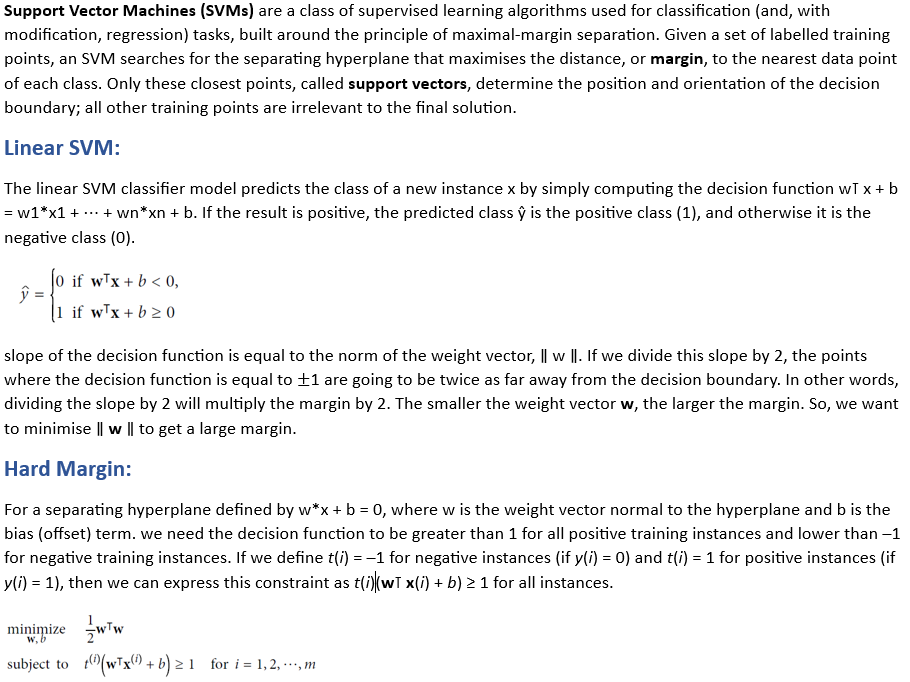

In [3]:
import numpy as np
import matplotlib.pyplot as plt

coefficients : 0.41 0.74 -4.20
x_test           : [2.5, 3.0, 4.5, 5.7]
y_test           : [3.9, 3.5, 5.0, 5.9]
model_predictions: [-1, -1, 1, 1]


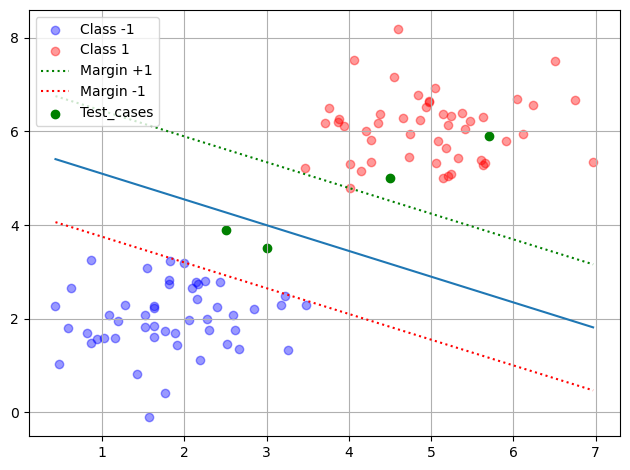

In [4]:
np.random.seed(42)
x0 = np.random.normal(loc=2.0, scale=0.8, size=50)
y0 = np.random.normal(loc=2.0, scale=0.8, size=50)
z0 = np.ones(50, dtype=int)*(-1)
x1 = np.random.normal(loc=5.0, scale=0.8, size=50)
y1 = np.random.normal(loc=6.0, scale=0.8, size=50)
z1 = np.ones(50, dtype=int)
x = np.concatenate((x0,x1))
y = np.concatenate((y0,y1))
z = np.concatenate((z0,z1))
m = len(x)

def get_constants(x,y,z):
    a,b,c = 0.0,0.0,0.0
    itr_max = 1000
    eta = 0.002
    for itr in range(itr_max):
        da,db,dc = 0.0,0.0,0.0
        for i in range(len(x)):
            if z[i]*(a*x[i]+b*y[i]+c) <= 1:
                da += - z[i]*x[i]
                db += - z[i]*y[i]
                dc += -z[i]
        a = a - da*eta
        b = b - db*eta
        c = c - dc*eta
    return a,b,c

def predictions(a,b,c,x,y):
    value = []
    for i in range(len(x)):
        value.append(a*x[i]+b*y[i]+c)
    predict=[]
    for ele in value:
        if ele < 0: predict.append(-1)
        else: predict.append(1)
    return predict
    
a,b,c = get_constants(x,y,z)
print('coefficients :',f'{a:.2f}',f'{b:.2f}',f'{c:.2f}')

x_test = [2.5,3.0,4.5,5.7]
y_test = [3.9,3.5,5.0,5.9]
print('x_test           :',x_test)
print('y_test           :',y_test)
predictions = predictions(a,b,c,x_test,y_test)
print('model_predictions:',predictions)

x_smooth = np.linspace(x.min(), x.max(), 200)
plt.grid()
plt.scatter(x0,y0,color='blue',alpha=0.4,label='Class -1')
plt.scatter(x1,y1,color='red',alpha=0.4,label='Class 1')
plt.plot(x_smooth, -(x_smooth*a + c)/b)
plt.plot(x_smooth, (1-(x_smooth*a + c))/b, color='green', linestyle='dotted',label='Margin +1')
plt.plot(x_smooth, (-1-(x_smooth*a + c))/b, color='red', linestyle='dotted',label='Margin -1')
plt.scatter(x_test,y_test,color='green',label='Test_cases')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

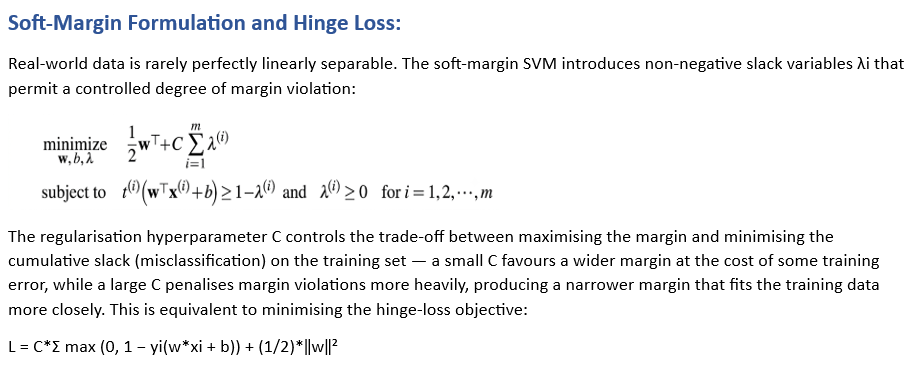

coefficients : 0.99 1.17 -7.31
x_test           : [2.5, 3.0, 4.5, 5.7]
y_test           : [3.9, 3.5, 5.0, 5.9]
model_predictions: [-1, -1, 1, 1]


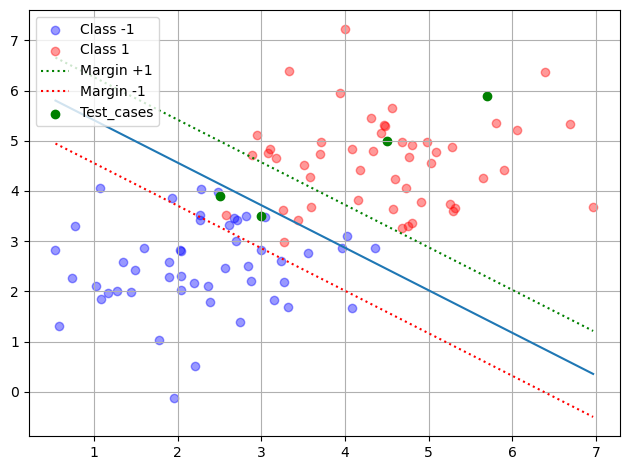

In [6]:
np.random.seed(42)
x0 = np.random.normal(loc=2.5, scale=1.0, size=50)
y0 = np.random.normal(loc=2.5, scale=1.0, size=50)
z0 = np.ones(50, dtype=int) * (-1)
x1 = np.random.normal(loc=4.5, scale=1.0, size=50)
y1 = np.random.normal(loc=4.5, scale=1.0, size=50)
z1 = np.ones(50, dtype=int)
x = np.concatenate((x0, x1))
y = np.concatenate((y0, y1))
z = np.concatenate((z0, z1))
m= len(x)

def get_constants(x,y,z,lambda_):
    a,b,c = 0.0,0.0,0.0
    itr_max = 1000
    eta = 0.002
    for itr in range(itr_max):
        da,db,dc = 0.0,0.0,0.0
        for i in range(len(x)):
            if z[i]*(a*x[i]+b*y[i]+c) >= 1:
                da += lambda_*a
                db += lambda_*b
                dc += 0
            else:
                da += lambda_*a - z[i]*x[i]
                db += lambda_*b - z[i]*y[i]
                dc += -z[i]
        a = a - da*eta
        b = b - db*eta
        c = c - dc*eta
    return a,b,c

def predictions(a,b,c,x,y):
    value = []
    for i in range(len(x)):
        value.append(a*x[i]+b*y[i]+c)
    predict=[]
    for ele in value:
        if ele < 0: predict.append(-1)
        else: predict.append(1)
    return predict
    
a,b,c = get_constants(x,y,z,0.01)
print('coefficients :',f'{a:.2f}',f'{b:.2f}',f'{c:.2f}')

x_test = [2.5,3.0,4.5,5.7]
y_test = [3.9,3.5,5.0,5.9]
print('x_test           :',x_test)
print('y_test           :',y_test)
predictions = predictions(a,b,c,x_test,y_test)
print('model_predictions:',predictions)

x_smooth = np.linspace(x.min(), x.max(), 200)
plt.grid()
plt.scatter(x0,y0,color='blue',alpha=0.4,label='Class -1')
plt.scatter(x1,y1,color='red',alpha=0.4,label='Class 1')
plt.plot(x_smooth, -(x_smooth*a + c)/b)
plt.plot(x_smooth, (1-(x_smooth*a + c))/b, color='green', linestyle='dotted',label='Margin +1')
plt.plot(x_smooth, (-1-(x_smooth*a + c))/b, color='red', linestyle='dotted',label='Margin -1')
plt.scatter(x_test,y_test,color='green',label='Test_cases')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()